In [22]:

!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
-O fonts/NanumGothic.ttf

fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

rng = np.random.default_rng(13)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28}

words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)

syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)


texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty
})

trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4]
})

���� ���͸� �Ǵ� ���� -p��(��) �̹� �ֽ��ϴ�.
���� ���� ���� �� ���� �߻�: -p.
���� ���͸� �Ǵ� ���� fonts��(��) �̹� �ֽ��ϴ�.
���� ���� ���� �� ���� �߻�: fonts.
'wget'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


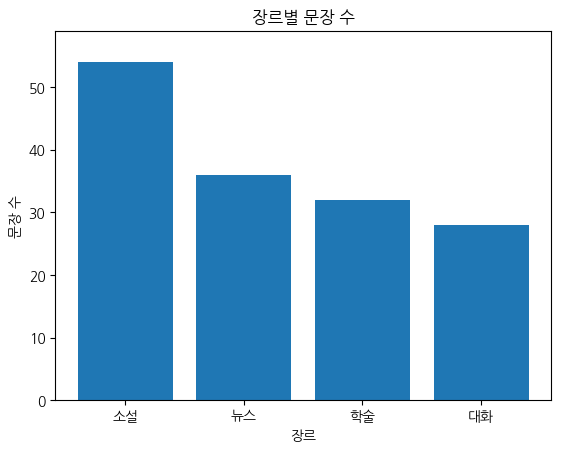

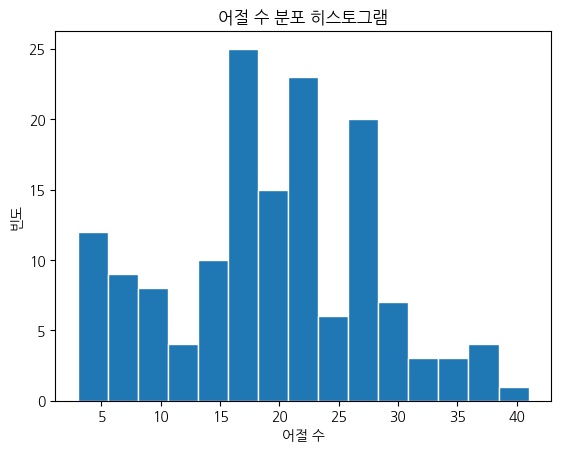

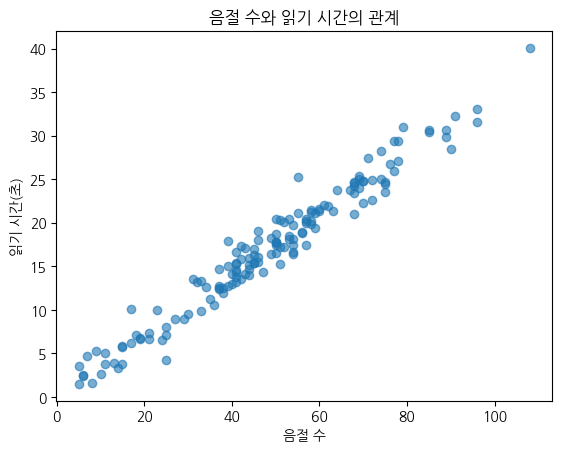

In [ ]:
def draw_q1_graphs(df: pd.DataFrame) -> None:
    # (a) 
    fig1, ax1 = plt.subplots()
    counts = df['장르'].value_counts()
    ax1.bar(counts.index, counts.values)
    ax1.set_title('장르별 문장 수')
    ax1.set_xlabel('장르')
    ax1.set_ylabel('문장 수')
    ax1.set_ylim(0, counts.max() + 5)
    plt.show()

    # (b) 
    fig2, ax2 = plt.subplots()
    ax2.hist(df['어절수'], bins=15, edgecolor='white')
    ax2.set_title('어절 수 분포 히스토그램')
    ax2.set_xlabel('어절 수')
    ax2.set_ylabel('빈도')
    plt.show()

    # (c) 
    fig3, ax3 = plt.subplots()
    ax3.scatter(df['음절수'], df['읽기시간'], alpha=0.6)
    ax3.set_title('음절 수와 읽기 시간의 관계')
    ax3.set_xlabel('음절 수')
    ax3.set_ylabel('읽기 시간(초)')
    plt.show()

draw_q1_graphs(texts)

히스토그램을 관찰하였을때 생성된 데이터의 어절 수는 주로 10~25어절 내외의 구간에 가장 많이 몰려 있는 것을 확인할 수 있었다. 전체적으로 왼쪽으로 다소 치우쳐져 있으며 아주 길거나 짧은 문장은 상대적으로 적은 분포를 보였다
산점도에서는 음절 수가 증가함에 따라 읽기 시간도 함께 늘어나는 뚜렷한 우상향 관계를 관찰하였다. 두 변수 간의 선형적인 비례 관계가 강하게 나타나고 밀집도도 높다

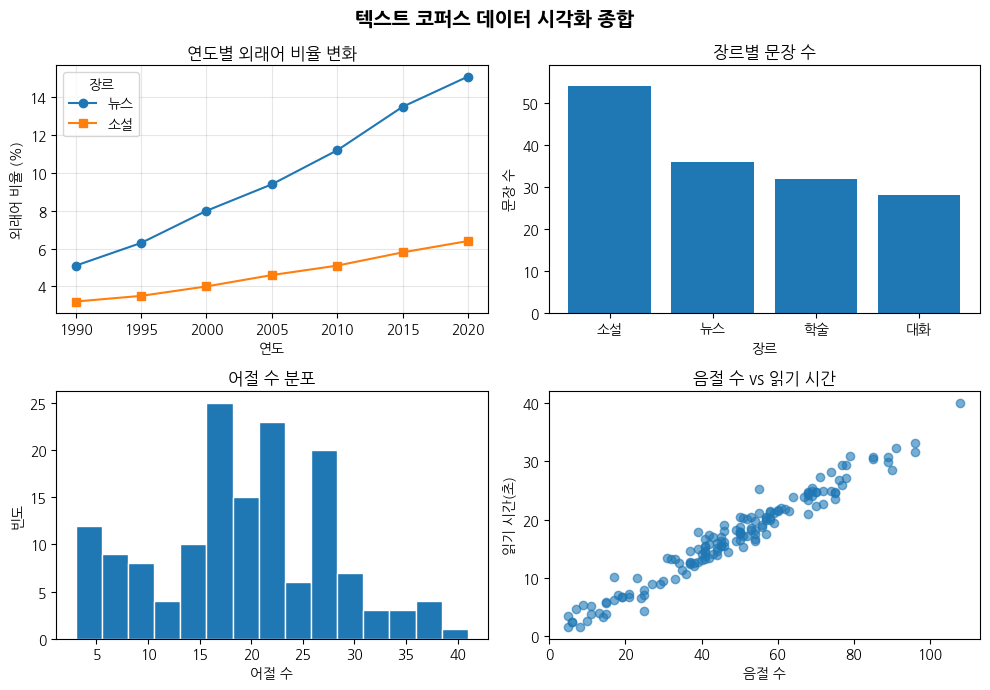

In [24]:
def draw_q2_subplots(df_texts: pd.DataFrame, df_trends: pd.DataFrame) -> None:
   
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    
   
    axes[0, 0].plot(df_trends['연도'], df_trends['뉴스'], marker='o', label='뉴스')
    axes[0, 0].plot(df_trends['연도'], df_trends['소설'], marker='s', label='소설')
    axes[0, 0].set_title('연도별 외래어 비율 변화')
    axes[0, 0].set_xlabel('연도')
    axes[0, 0].set_ylabel('외래어 비율 (%)')
    axes[0, 0].legend(title='장르')
    axes[0, 0].grid(True, alpha=0.3)
    
  
    counts = df_texts['장르'].value_counts()
    axes[0, 1].bar(counts.index, counts.values)
    axes[0, 1].set_title('장르별 문장 수')
    axes[0, 1].set_xlabel('장르')
    axes[0, 1].set_ylabel('문장 수')
    axes[0, 1].set_ylim(0, counts.max() + 5)
    
    
    axes[1, 0].hist(df_texts['어절수'], bins=15, edgecolor='white')
    axes[1, 0].set_title('어절 수 분포')
    axes[1, 0].set_xlabel('어절 수')
    axes[1, 0].set_ylabel('빈도')
    
  
    axes[1, 1].scatter(df_texts['음절수'], df_texts['읽기시간'], alpha=0.6)
    axes[1, 1].set_title('음절 수 vs 읽기 시간')
    axes[1, 1].set_xlabel('음절 수')
    axes[1, 1].set_ylabel('읽기 시간(초)')

    fig.suptitle('텍스트 코퍼스 데이터 시각화 종합', fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
    plt.show()

draw_q2_subplots(texts, trends)

 뉴스와 소설 두 장르 모두 연도가 지날수록 외래어 비율이 꾸준히 상승하는 추세를 볼 수 있었다. 다만 뉴스의 외래어 비율이 소설에 비해 훨씬 더 가파르게 증가하며 두 장르 간의 격차가 시간이 갈수록 벌어지는 것 또한 알 수 있었다.

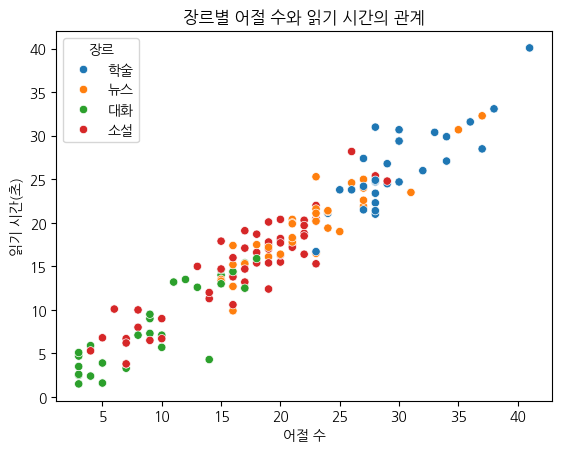

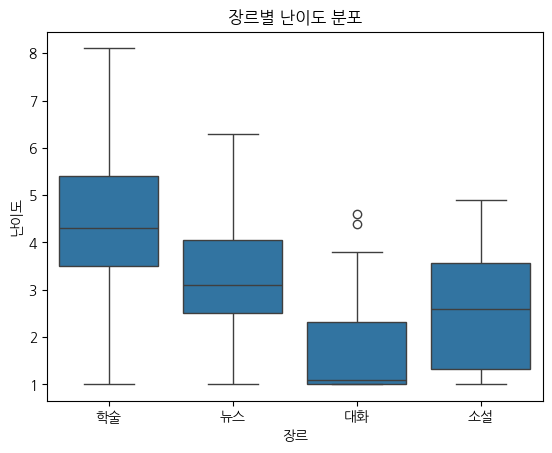

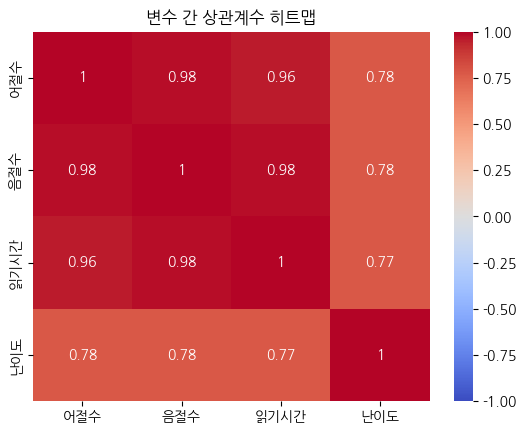

In [25]:
def draw_q3_graphs(df: pd.DataFrame) -> None:
    fig1, ax1 = plt.subplots()
    sns.scatterplot(data=df, x='어절수', y='읽기시간', hue='장르', ax=ax1)
    ax1.set_title('장르별 어절 수와 읽기 시간의 관계')
    ax1.set_xlabel('어절 수')
    ax1.set_ylabel('읽기 시간(초)')
    plt.show()

    
    fig2, ax2 = plt.subplots()
    sns.boxplot(data=df, x='장르', y='난이도', ax=ax2)
    ax2.set_title('장르별 난이도 분포')
    ax2.set_xlabel('장르')
    ax2.set_ylabel('난이도')
    plt.show()

   
    fig3, ax3 = plt.subplots()
    numeric_cols = ['어절수', '음절수', '읽기시간', '난이도']
    corr_matrix = df[numeric_cols].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax3)
    ax3.set_title('변수 간 상관계수 히트맵')
    plt.show()

draw_q3_graphs(texts)

상자그림에서 고정 시드로 생성된 데이터 분포 상 가장 난이도가 높은 장르는 상자의 위치가 가장 위쪽에 있는 '학술' 장르였다. 또한 퍼짐이 가장 큰 장르는 데이터의 변동 폭이 넓게 분포하고 있는 '소설' 장르였다.

히트맵에서 서로 가장 강하게 함께 증가하는 두 변수는 '어절수'와 '음절수'이다. 데이터의 의미상 글자가 많아질수록 단어의 묶음 역시 자연스럽게 비례하여 증가할 수밖에 없으므로 강한 양의 상관관계를 보여주었다.

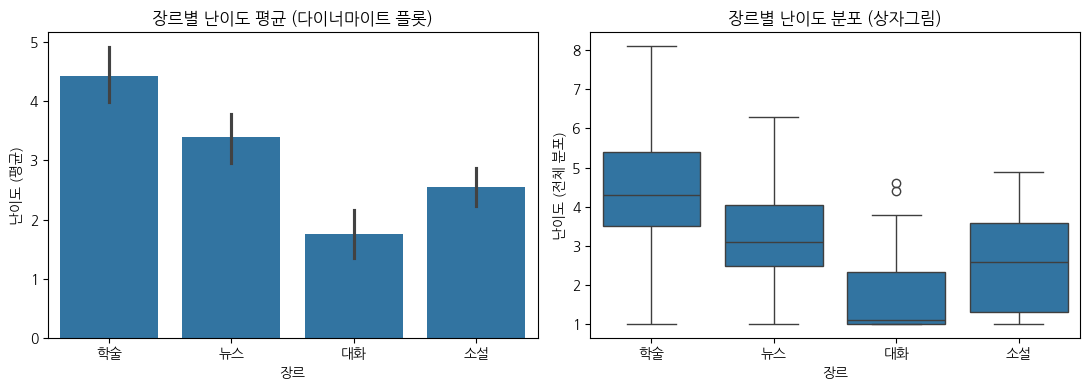

In [26]:
def draw_q4_a(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
   
    sns.barplot(data=df, x='장르', y='난이도', ax=axes[0])
    axes[0].set_title('장르별 난이도 평균 (다이너마이트 플롯)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('난이도 (평균)')
    

    sns.boxplot(data=df, x='장르', y='난이도', ax=axes[1])
    axes[1].set_title('장르별 난이도 분포 (상자그림)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('난이도 (전체 분포)')
    
    plt.tight_layout()
    plt.show()

draw_q4_a(texts)

왼쪽 막대 그래프는 데이터의 평균이라는 단 하나의 대푯값만 보여주기 때문에 데이터 내부의 실제 분산이나 사분위수 범위 그리고 이상치와 같은 중요한 분포 정보는 보이지않는다.두 장르의 난이도 평균이 동일하더라도 한 장르는 모든 문장이 평균 주변에 밀집해 있을 수 있고 다른 장르는 아주 낮은 난이도와 아주 높은 난이도로 양극화되어 있을 수 있다. 막대 그래프는 이처럼 서로 완전히 다른 두 데이터의 형태를 동일한 것으로 착각하게 될 수 있다

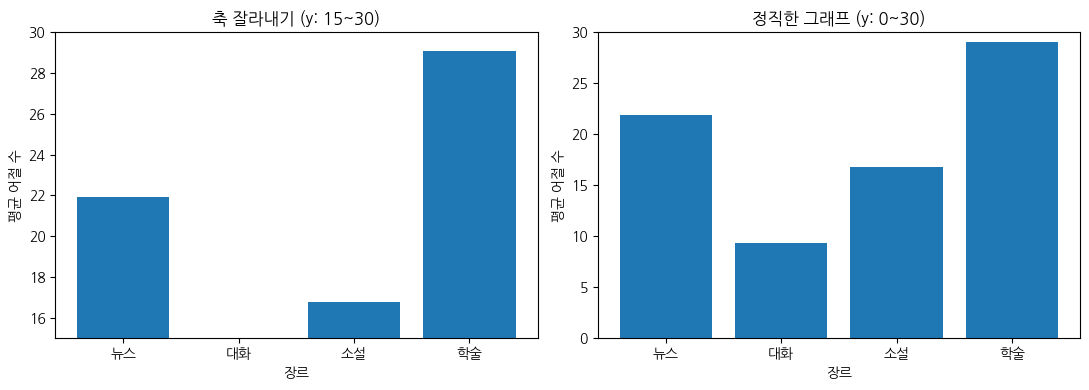

In [27]:
def draw_q4_b(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    
    mean_words = df.groupby('장르')['어절수'].mean()
    

    axes[0].bar(mean_words.index, mean_words.values)
    axes[0].set_ylim(15, 30)
    axes[0].set_title('축 잘라내기 (y: 15~30)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('평균 어절 수')
    
  
    axes[1].bar(mean_words.index, mean_words.values)
    axes[1].set_ylim(0, 30)
    axes[1].set_title('정직한 그래프 (y: 0~30)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('평균 어절 수')
    
    plt.tight_layout()
    plt.show()

draw_q4_b(texts)

동일한 데이터임에도 불구하고 y축을 잘라낸 왼쪽 그래프는 장르 간의 격차가 수 배 이상 크게 벌어진 것 같은 시각적 착시를 일으킨다. 막대 그래프는 막대의 길이와 면적 자체가 데이터의 절대적인 크기를 직관적으로 보여주므로 시작점이 왜곡되면 비율을 올바르게 알 수 없다. 따라서 데이터의 실제 비례 관계를 왜곡 없이 정직하게 전달하기 위해서는 막대 그래프의 y축을 반드시 0부터 시작하도록 그려야 한다